In [1]:
import pandas as pd
import micom
from plotnine import *

## Build Models
First, build MCMMs for the _A. caccae_ and _B. uniformis_ co-culture and _A. caccae_ mono-culture

In [2]:
agora = './agora103_refseq216_species_1.qza'
taxonomy_ac_bu = pd.DataFrame({'id':['Anaerostipes_caccae', 'Bacteroides_uniformis'],
                         'species':['Anaerostipes caccae', 'Bacteroides uniformis'],
                         'sample_id':['ac_bu','ac_bu'],
                         'abundance':[0.5,0.5]})
taxonomy_ac = pd.DataFrame({'id':['Anaerostipes_caccae'],
                         'species':['Anaerostipes caccae'],
                         'sample_id':['ac'],
                         'abundance':[1.0]})

ac_bu = micom.Community(taxonomy_ac_bu, model_db=agora)

ac = micom.Community(taxonomy_ac, model_db=agora)

Output()

Output()

## Load Media 
Load a pre-constructed media representing DM38

In [3]:
# Load DM38 medium
medium = pd.read_csv('./DM38_media.csv', index_col = 0)

# Make inulin medium 
medium_inulin = pd.concat([medium, 
                           pd.DataFrame({'metabolite':['inulin_m'],
                                         'flux':[1],
                                         'reaction':['EX_inulin_m']}, 
                                        index = ['EX_inulin_m'])
                          ])

## Grow Models
Simulate growth of the co-culture and monoculture models, with and without added inulin

In [4]:
## AC/BU without fiber
ac_bu.medium = medium.flux
sol_ac_bu_noFiber = ac_bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

## AC without fiber
ac.medium = medium.flux
sol_ac_noFiber = ac.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

## AC/BU with fiber
ac_bu.medium = medium_inulin.flux
sol_ac_bu_fiber = ac_bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

## AC with fiber
ac.medium = medium_inulin.flux
sol_ac_fiber = ac.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

## Isolate Butyrate Results
For the four growth simulations, isolate predictions for butyrate production 

In [5]:
res1 = sol_ac_bu_noFiber.fluxes['EX_but_m'].loc['medium']
res2 = sol_ac_noFiber.fluxes['EX_but_m'].loc['medium']
res3 = sol_ac_bu_fiber.fluxes['EX_but_m'].loc['medium']
res4 = sol_ac_fiber.fluxes['EX_but_m'].loc['medium']

## Plot results 
Plot predicted butyrate production for each context

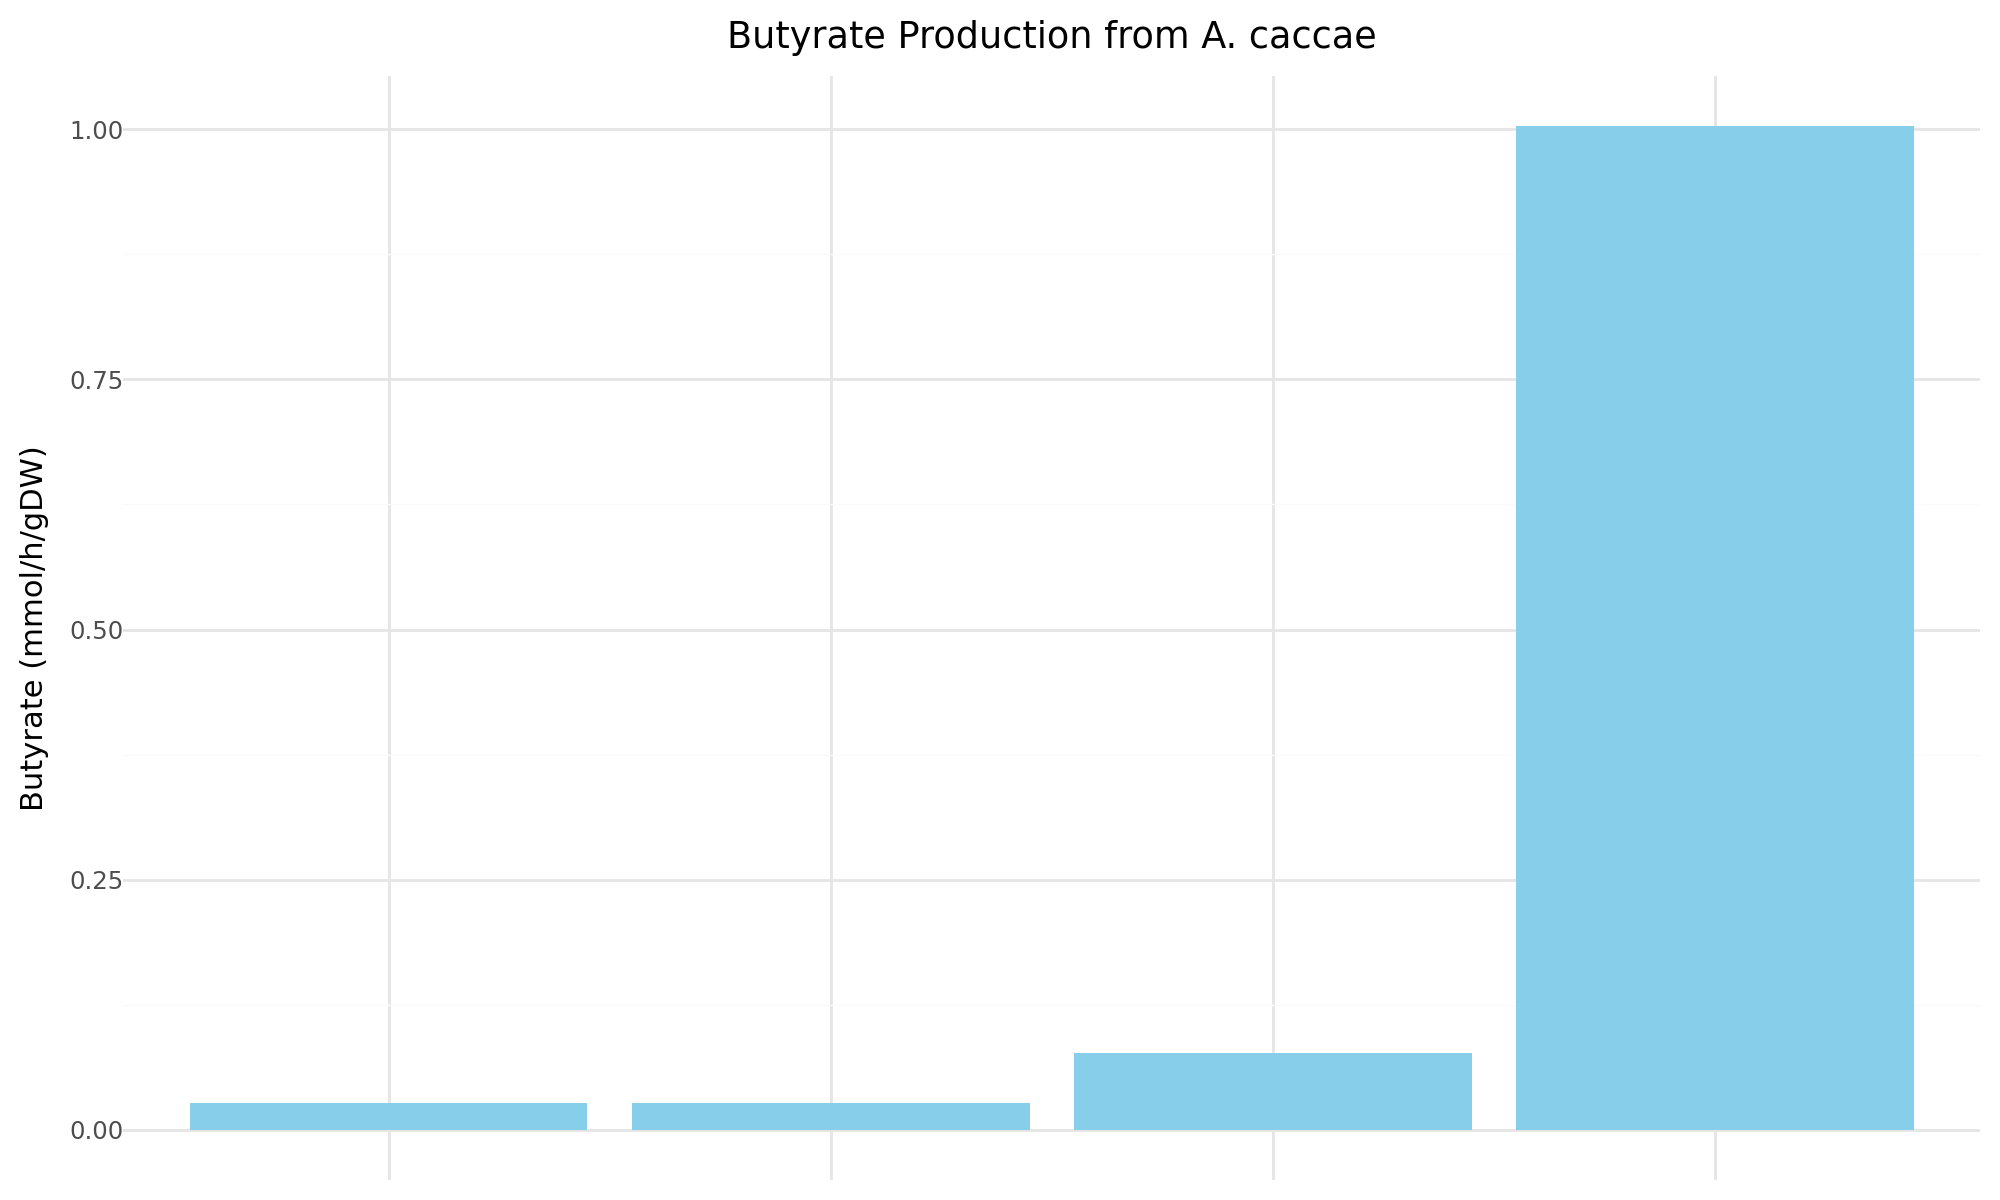

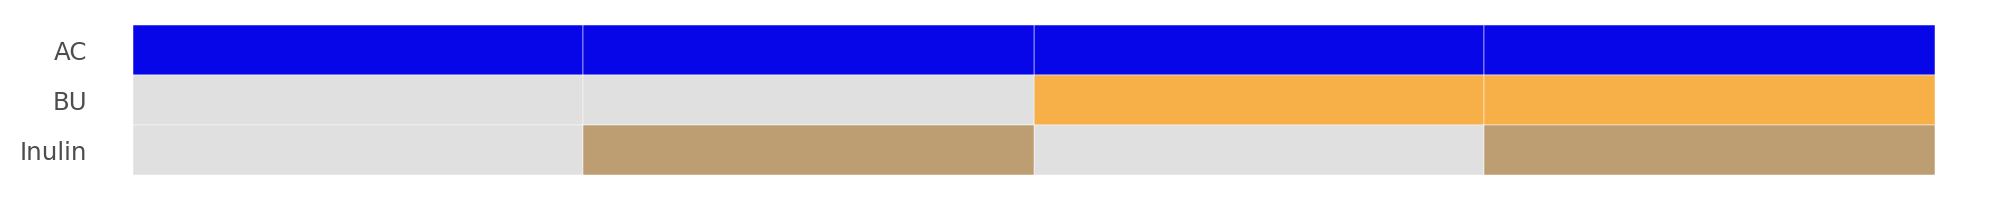

In [6]:
## Build data frame
to_plt = pd.DataFrame({'Butyrate':[res1 ,res2, res3, res4],
                       'Co-Culture':['AC+BU Co-Culture','AC Monoculture',
                                    'AC+BU Co-Culture','AC Monoculture'], 
                       'Fiber':['','',' + inulin',' + inulin']})

to_plt['Condition'] = to_plt['Co-Culture']+to_plt['Fiber']

## Set order
desired_order = ['AC Monoculture',
                 'AC Monoculture + inulin',
                 'AC+BU Co-Culture',
                 'AC+BU Co-Culture + inulin',

]
to_plt['Condition'] = pd.Categorical(to_plt['Condition'], categories=desired_order, ordered=True)

# Add binary flags
to_plt['AC'] = 1  # always present
to_plt['BU'] = to_plt['Co-Culture'].str.contains('BU').astype(int)
to_plt['Inulin'] = to_plt['Fiber'].str.contains('inulin').astype(int)

# Melt into long format for component presence
indicator_df = to_plt.melt(id_vars=['Condition'], value_vars=['AC', 'BU', 'Inulin'], var_name='Component', value_name='Present')

indicator_df['fill_key'] = indicator_df['Component'] + '_' + indicator_df['Present'].astype(str)
indicator_df['Component'] = pd.Categorical(
    indicator_df['Component'],
    categories=['Inulin', 'BU', 'AC'],
    ordered=True
)


# Define custom colors for each row (present = color, absent = light gray)
fill_colors = {
    'AC_1': '#0706e9',       
    'AC_0': '#E0E0E0',       
    'BU_1': '#f7af48',       
    'BU_0': '#E0E0E0',
    'Inulin_1': '#bd9d72',   
    'Inulin_0': '#E0E0E0'
}

# Plot the main bar plot
bar = (
    ggplot(to_plt, aes(x='Condition', y='Butyrate')) +
    geom_bar(stat='identity', fill='skyblue') +
    theme_minimal() +
    labs(title='Butyrate Production from A. caccae', x='', y='Butyrate (mmol/h/gDW)') +
    theme(figure_size=(10,6), axis_text_x=element_blank(), axis_ticks_major_x=element_blank())
)

# Add tile plot underneath to indicate component presence
tiles = (
    ggplot(indicator_df, aes(x='Condition', y='Component', fill='fill_key')) +
    geom_tile(color='white') +
    scale_fill_manual(values=fill_colors) +
    theme_minimal() +
    labs(x='', y='') +
    theme(
        figure_size=(10, 1),
        axis_text_x=element_blank(),
        legend_position='none',
        panel_grid=element_blank()
    )
)

bar.show()
tiles.show()

## Investigate Inulin Utilization
Inulin is only utilized when BU is present, determine the mechanism by which this occurs by examining fluxes

In [7]:
print(ac_bu.reactions.get_by_id('EX_inulin_m').reaction)
print(sol_ac_bu_fiber.fluxes['EX_inulin_m'].loc['medium'])

inulin_m <=> 
-0.9800613622520551


1 mmol of inulin was added to the media, and nearly all of it is predicted to be imported. Next, look at inulinase activity, and outputs. 

In [8]:
print(ac_bu.reactions.get_by_id('INULINASEe__Bacteroides_uniformis').reaction)
print(sol_ac_bu_fiber.fluxes['INULINASEe'].loc['Bacteroides_uniformis'])

25.0 h2o[e]__Bacteroides_uniformis + inulin[e]__Bacteroides_uniformis --> 25.0 fru[e]__Bacteroides_uniformis + kestopt[e]__Bacteroides_uniformis
1.9601227245041102


The inulin is being degraded extracellularly by _B. uniformis_, and yielding 25 mmol of fructose per mmol of inulin. Let's see if that is being exported. 

In [9]:
print(ac_bu.reactions.get_by_id('EX_fru(e)__Bacteroides_uniformis').reaction)
print(sol_ac_bu_fiber.fluxes['EX_fru(e)'].loc['Bacteroides_uniformis'])

fru[e]__Bacteroides_uniformis <=> 0.5 fru_m
18.118146693010303


Looks like a lot of fructose is being exported and is availble for _A. caccae_ to import. Let's compare fructose imports into _A. caccae_ between the fiber and no fiber conditions

In [10]:
print(ac_bu.reactions.get_by_id('EX_fru(e)__Anaerostipes_caccae').reaction)
print('With added inulin:')
print(sol_ac_bu_fiber.fluxes['EX_fru(e)'].loc['Anaerostipes_caccae'])

print('Without added inulin:')
print(sol_ac_bu_noFiber.fluxes['EX_fru(e)'].loc['Anaerostipes_caccae'])

fru[e]__Anaerostipes_caccae <=> 0.5 fru_m
With added inulin:
-17.641363540209575
Without added inulin:
-9.247085473686628


So, the added inulin is being degraded extracellularly into fructose by _B. uniformis_, which is then exported and re-imported by _A. caccae_, leading to an increase in butyrate production. 